In [23]:
import correctionlib
from correctionlib import convert

In [24]:
trghist = "/home/jieun/working/monotopRun3/ElePOG/2022preLoose/egammaEffi.txt_EGM2D.root:EGamma_SF2D"

In [25]:
corr = convert.from_uproot_THx(trghist)

In [26]:
corr

Correction(name='h2_scaleFactorsEGamma', description=None, version=0, inputs=[Variable(name='axis0', type='real', description=None), Variable(name='axis1', type='real', description=None)], output=Variable(name='out', type='real', description=None), generic_formulas=None, data=MultiBinning(nodetype='multibinning', inputs=['axis0', 'axis1'], edges=[[-2.5, -2.0, -1.566, -1.444, -0.8, 0.0, 0.8, 1.444, 1.566, 2.0, 2.5], [25.0, 30.0, 32.0, 35.0, 40.0, 45.0, 50.0, 75.0, 100.0, 200.0, 500.0]], content=[0.055607475340366364, 0.1709185391664505, 0.5157450437545776, 0.9543377161026001, 1.0435870885849, 1.0491182804107666, 1.0431441068649292, 1.0070955753326416, 0.9956380724906921, 1.0459471940994263, 0.042559392750263214, 0.15981988608837128, 0.5084160566329956, 0.9192914962768555, 1.0071616172790527, 1.0364044904708862, 1.0267274379730225, 1.0265312194824219, 1.0172159671783447, 0.9556208848953247, 0.3013100326061249, 0.31306153535842896, 0.7218559384346008, 0.8646666407585144, 1.048984289169311

In [28]:
evaluator = corr.to_evaluator()

In [38]:
evaluator

In [13]:
evaluator.inputs

In [35]:
import numpy as np
eta = np.array([1.1, 1.3])
pt = np.array([33, 46])


In [ ]:
import json
from correctionlib.schemav2 import CorrectionSet
import correctionlib
from correctionlib import convert

year = '2022pre'
cutbased = 'Loose'

trghist = "/home/jieun/working/monotopRun3/ElePOG/2022preLoose/egammaEffi.txt_EGM2D.root:EGamma_SF2D"

corr = convert.from_uproot_THx(trghist)
cset = CorrectionSet(schema_version=2, corrections=[corr])

with open("/home/jieun/working/monotopRun3/ElePOG/2022preLoose/electron_sf.json", "w") as f:
    f.write(cset.json(exclude_unset=True))

In [31]:
cset = correctionlib.CorrectionSet.from_file("electron_sf.json")


In [32]:
cset

In [36]:
sf = cset["h2_scaleFactorsEGamma"].evaluate(eta, pt)

In [37]:
sf

array([0.85318655, 0.97528893])

## Efficiency 2D plot

In [39]:
eta_edges = [-2.5, -2.0, -1.566, -1.444, -0.8, 0.0, 0.8, 1.444, 1.566, 2.0, 2.5]
pt_edges  = [25.0, 30.0, 32.0, 35.0, 40.0, 45.0, 50.0, 75.0, 100.0, 200.0, 500.0]

In [44]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

f = uproot.open("ElePOG/2022preLoose/egammaEffi.txt_EGM2D.root")

hist = f["EGamma_SF2D"]

In [46]:
values = hist.values()
eta_edges = hist.axes[0].edges()
pt_edges = hist.axes[1].edges()
values = values.T

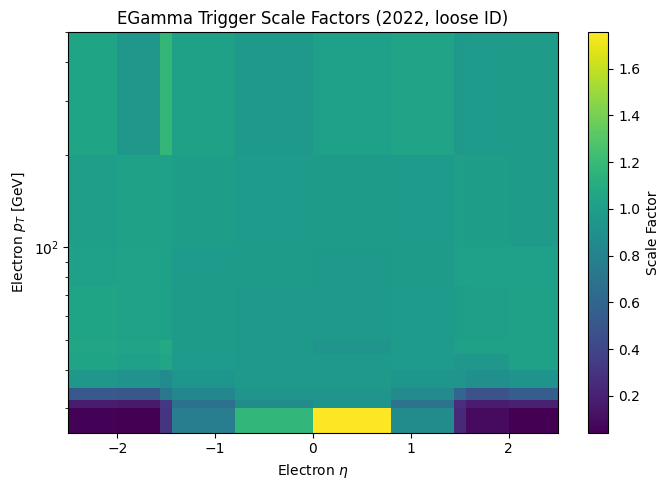

In [65]:
plt.figure(figsize=(7,5))

plt.pcolormesh(eta_edges, pt_edges, values, shading="auto")

plt.xlabel("Electron $\eta$")
plt.ylabel("Electron $p_T$ [GeV]")


plt.yscale("log")

plt.colorbar(label="Scale Factor")

plt.title("EGamma Trigger Scale Factors (2022, loose ID)")

plt.tight_layout()
plt.savefig('./ElePOG/eleTrgSF22_looseID.png')
plt.show()

In [48]:
eta_centers = 0.5*(eta_edges[:-1] + eta_edges[1:])
pt_centers = 0.5*(pt_edges[:-1] + pt_edges[1:])

for i, pt in enumerate(pt_centers):
    for j, eta in enumerate(eta_centers):
        plt.text(eta, pt, f"{values[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)

ValueError: Image size of 2276x129408 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [30]:
## For decaf
import json
from correctionlib.schemav2 import CorrectionSet
import correctionlib
from correctionlib import convert

year = '2022pre'
cutbased = 'Loose'

trghist = "data/ElectronTrigEff/"+year+"/"+cutbased+"/egammaEffi.txt_EGM2D.root:EGamma_SF2D"

corr = convert.from_uproot_THx(trghist)
cset = CorrectionSet(schema_version=2, corrections=[corr])

with open("data/ElectronTrigEff/"+year+"/"+cutbased+"electron_sf.json", "w") as f:
    f.write(cset.json(exclude_unset=True))